In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [51]:
df = pd.read_csv(r"C:\Machine learning Campusx\Data\lineardata.csv")

In [52]:
df.head(5)

,x,y
0,74.128461,357.046360
1,39.705725,206.225240
2,1.327203,2.163316
3,86.752451,412.080923
4,32.803825,171.032648


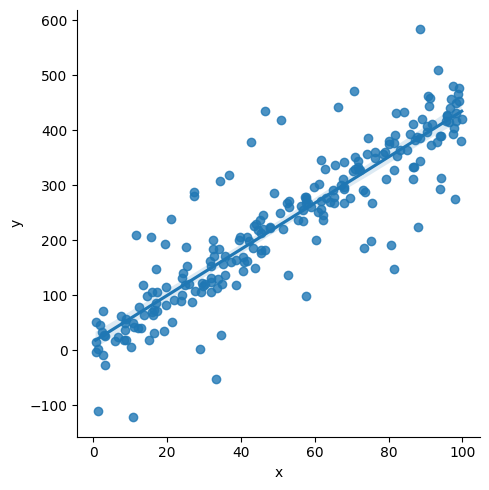

In [53]:
sns.lmplot(data = df, x = "x" , y = "y")

<Axes: ylabel='x'>

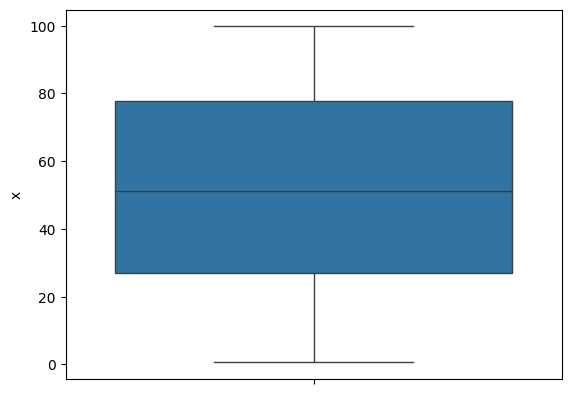

In [54]:
sns.boxplot(df['x'])

<Axes: ylabel='y'>

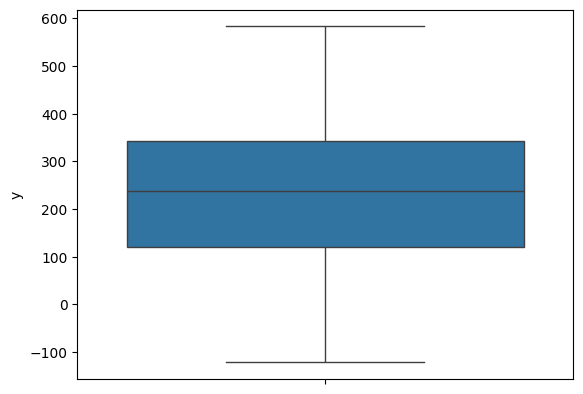

In [55]:
sns.boxplot(df['y'])

C:\Users\gdeep\AppData\Local\Temp\ipykernel_22312\703526615.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["x"],ax = ax1)
C:\Users\gdeep\AppData\Local\Temp\ipykernel_22312\703526615.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["y"], ax = ax2)


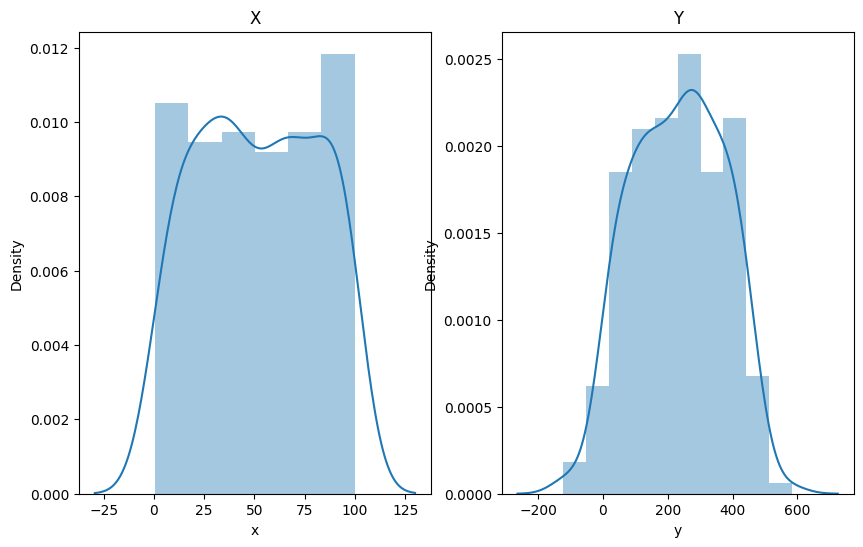

In [56]:
fig , (ax1 , ax2) = plt.subplots(figsize =(10,6), ncols = 2)
ax1.set_title("X")
sns.distplot(df["x"],ax = ax1)
ax2.set_title("Y")
sns.distplot(df["y"], ax = ax2)
plt.show()

In [57]:
from scipy.stats import zscore
df['zscore'] = zscore(df['x'])
df = df[abs(df['zscore']) < 3]

In [58]:
df.shape

(230, 3)

In [59]:
X  = df[['x']]
y = df[['y']]

In [60]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train, y_test = train_test_split(X, y , test_size = 0.3, random_state = 12)

In [61]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

In [66]:
min_max  = MinMaxScaler()
standard = StandardScaler()
robust = RobustScaler()

min_max.fit(X_train)
standard.fit(X_train)
robust.fit(X_train)

X_train_min_max_scaler = min_max.transform(X_train)
X_train_standard_scaler = standard.transform(X_train)
X_train_robust_scaler = robust.transform(X_train)

X_test_min_max_scaler = min_max.transform(X_test)
X_test_standard_scaler = standard.transform(X_test)
X_test_robust_scaler = robust.transform(X_test)

In [67]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr_min_max = LinearRegression()
lr_standard = LinearRegression()
lr_robust = LinearRegression()

lr.fit(X_train,y_train)
lr_min_max.fit(X_train_min_max_scaler , y_train)
lr_standard.fit(X_train_standard_scaler , y_train)
lr_robust.fit(X_train_robust_scaler , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[214.59]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[246.88]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[7.43]


In [68]:
y_pred = lr.predict(X_test)

y_pred_min_max = lr_min_max.predict(X_test_min_max_scaler)

y_pred_standard = lr_standard.predict(X_test_standard_scaler)

y_pred_robust = lr_robust.predict(X_test_robust_scaler)

In [69]:
from sklearn.metrics import r2_score

In [70]:
print(f"Normal : {r2_score(y_test, y_pred)}" )
print(f"MinMax : {r2_score(y_test, y_pred_min_max)}" )
print(f"Standard : {r2_score(y_test, y_pred_standard)}" )
print(f"Robust : {r2_score(y_test, y_pred_robust)}" )

Normal : 0.773111791859521
MinMax : 0.773111791859521
Standard : 0.773111791859521
Robust : 0.773111791859521


In [ ]:
# So there is no difference if there are no outliers